### Importo las librerías necesarias

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [26]:
plt.style.use('default')
sns.set_palette('husl')

### Cargo el dataset 20 Newsgroups
Este dataset contiene documentos de grupos de noticias clasificados en 20 categorías.

In [27]:

news_train = fetch_20newsgroups(subset="train", shuffle=True, random_state=42)
news_test = fetch_20newsgroups(subset="test", shuffle=True, random_state=42)

### Analizo la estructura del dataset

In [28]:
print(f"Documentos de entrenamiento: {len(news_train.data):,}")
print(f"Documentos de prueba: {len(news_test.data):,}")
print(f"Total de documentos: {len(news_train.data) + len(news_test.data):,}")
print(f"Número de categorías: {len(news_train.target_names)}")

Documentos de entrenamiento: 11,314
Documentos de prueba: 7,532
Total de documentos: 18,846
Número de categorías: 20


### Categorías disponibles

In [29]:
for i, category in enumerate(news_train.target_names, 1):
    print(f"{i:2d}. {category}")

 1. alt.atheism
 2. comp.graphics
 3. comp.os.ms-windows.misc
 4. comp.sys.ibm.pc.hardware
 5. comp.sys.mac.hardware
 6. comp.windows.x
 7. misc.forsale
 8. rec.autos
 9. rec.motorcycles
10. rec.sport.baseball
11. rec.sport.hockey
12. sci.crypt
13. sci.electronics
14. sci.med
15. sci.space
16. soc.religion.christian
17. talk.politics.guns
18. talk.politics.mideast
19. talk.politics.misc
20. talk.religion.misc


### Muestro un ejemplo de documento del dataset

In [30]:
print(f"Categoría: {news_train.target_names[news_train.target[0]]}")
print(news_train.data[0][:400] + "...")

Categoría: rec.autos
From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
th...


### Analizo la distribución de documentos por categoría

In [31]:
from collections import Counter

train_counts = Counter(news_train.target)
distribution_df = pd.DataFrame([
    {'Categoría': news_train.target_names[cat], 'Cantidad': count}
    for cat, count in sorted(train_counts.items())
])

print(distribution_df.to_string(index=False))

               Categoría  Cantidad
             alt.atheism       480
           comp.graphics       584
 comp.os.ms-windows.misc       591
comp.sys.ibm.pc.hardware       590
   comp.sys.mac.hardware       578
          comp.windows.x       593
            misc.forsale       585
               rec.autos       594
         rec.motorcycles       598
      rec.sport.baseball       597
        rec.sport.hockey       600
               sci.crypt       595
         sci.electronics       591
                 sci.med       594
               sci.space       593
  soc.religion.christian       599
      talk.politics.guns       546
   talk.politics.mideast       564
      talk.politics.misc       465
      talk.religion.misc       377


### Visualizo la distribución con un gráfico

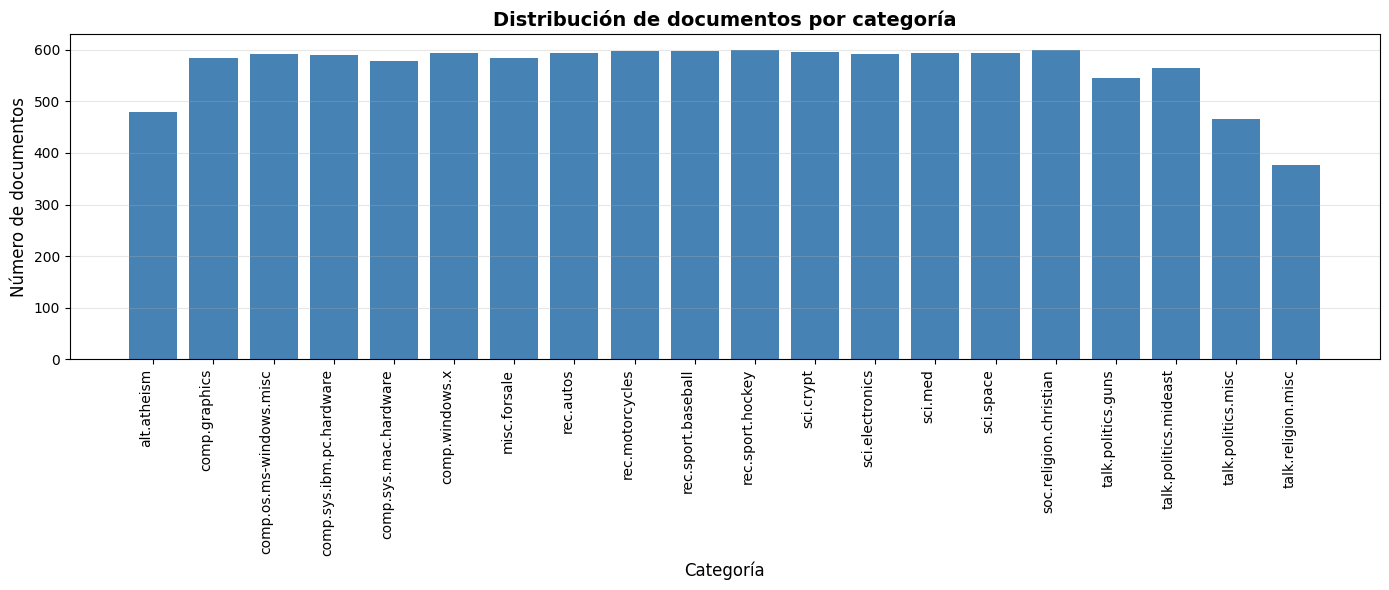

In [32]:
plt.figure(figsize=(14, 6))
plt.bar(range(len(distribution_df)), distribution_df['Cantidad'], color='steelblue')
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Número de documentos', fontsize=12)
plt.title('Distribución de documentos por categoría', fontsize=14, fontweight='bold')
plt.xticks(range(len(distribution_df)), distribution_df['Categoría'], rotation=90, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Creo el vectorizador TF-IDF

In [33]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.5,
    min_df=2,
    ngram_range=(1, 2),
    sublinear_tf=True
)

### Aplico la vectorización a los datos de entrenamiento

In [34]:
X_train = vectorizer.fit_transform(news_train.data)
y_train = news_train.target

### Transformo los datos de prueba

In [35]:
X_test = vectorizer.transform(news_test.data)
y_test = news_test.target

### Configuro el experimento en MLflow
MLflow me permite registrar y trackear todos los experimentos.

In [36]:
mlflow.set_experiment("20newsgroups_classification")

<Experiment: artifact_location='/Users/juandiego/Documents/study/keepcoding/prueba-mlops-llmops/mlruns/1', creation_time=1769702186148, experiment_id='1', last_update_time=1769702186148, lifecycle_stage='active', name='20newsgroups_classification', tags={'mlflow.experimentKind': 'custom_model_development'}>

### Inicio un run de MLflow para registrar todo el proceso

In [37]:
mlflow.start_run(run_name="LinearSVC_TF-IDF_Final")

<ActiveRun: >

### Registro los hiperparámetros del vectorizador en MLflow

In [38]:
mlflow.log_param("vectorizer", "TfidfVectorizer")
mlflow.log_param("stop_words", "english")
mlflow.log_param("max_df", 0.5)
mlflow.log_param("min_df", 2)
mlflow.log_param("ngram_range", "(1,2)")
mlflow.log_param("sublinear_tf", True)
mlflow.log_param("vocabulary_size", X_train.shape[1])

305504

### Creo el modelo LinearSVC

In [39]:

model = LinearSVC(
    C=1.0,
    max_iter=2000,
    random_state=42
)

### Registro los hiperparámetros del modelo en MLflow

In [40]:
mlflow.log_param("model_type", "LinearSVC")
mlflow.log_param("C", 1.0)
mlflow.log_param("max_iter", 2000)
mlflow.log_param("random_state", 42)

42

### Entreno el modelo con los datos de entrenamiento

In [41]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

### Hago predicciones sobre el conjunto de prueba

In [42]:
y_pred = model.predict(X_test)

print(f"{len(y_pred)} predicciones")

7532 predicciones


### Calculo las métricas de evaluación principales
Accuracy, Precision, Recall, F1-Score

In [43]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Accuracy:  0.8659 (86.59%)
Precision: 0.8679
Recall:    0.8659
F1-Score:  0.8650


### Registro las métricas en MLflow

In [44]:
mlflow.log_metric("accuracy", accuracy)
mlflow.log_metric("precision", precision)
mlflow.log_metric("recall", recall)
mlflow.log_metric("f1_score", f1)

### Genero el reporte de clasificación detallado
Este reporte muestra precision, recall y f1-score para cada categoría.

In [45]:
print(classification_report(y_test, y_pred, target_names=news_test.target_names))

                          precision    recall  f1-score   support

             alt.atheism       0.86      0.80      0.83       319
           comp.graphics       0.76      0.83      0.80       389
 comp.os.ms-windows.misc       0.81      0.78      0.79       394
comp.sys.ibm.pc.hardware       0.72      0.76      0.74       392
   comp.sys.mac.hardware       0.84      0.87      0.85       385
          comp.windows.x       0.88      0.79      0.83       395
            misc.forsale       0.83      0.91      0.87       390
               rec.autos       0.94      0.90      0.92       396
         rec.motorcycles       0.95      0.97      0.96       398
      rec.sport.baseball       0.92      0.96      0.94       397
        rec.sport.hockey       0.95      0.98      0.97       399
               sci.crypt       0.93      0.94      0.94       396
         sci.electronics       0.82      0.79      0.81       393
                 sci.med       0.92      0.87      0.89       396
         

### Guardo el modelo entrenado en MLflow

In [46]:
mlflow.sklearn.log_model(model, "linear_svc_model")

2026/01/29 15:42:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/Users/juandiego/Documents/study/keepcoding/prueba-mlops-llmops/venv/lib/python3.14/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


### Guardo el vectorizador en MLflow

In [47]:
mlflow.sklearn.log_model(vectorizer, "tfidf_vectorizer")

2026/01/29 15:42:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/29 15:42:43 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


### Finalizo el run de MLflow

In [48]:
mlflow.end_run()

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.8659
Precision: 0.8679
Recall: 0.8659
F1-Score: 0.8650
